# 회원 이탈 예측

`data/gym_churn_us.csv` (4,000명) 기반. 가입기간·수업 참여빈도 등 이용 행동 데이터로 트리 기반 모델(결정트리, 랜덤포레스트)을 학습해 이탈 여부를 예측하고,
하이퍼파라미터 튜닝을 통한 성능 개선 및 Feature Importance 기반 인사이트 도출을 목표로 한다.

## 컬럼 설명

| 컬럼명 | 설명 |
|---|---|
| `gender` | 고객의 성별 (0/1) |
| `Near_Location` | 헬스장 근처 거주 여부 |
| `Partner` | 제휴 파트너를 통한 가입 여부 |
| `Promo_friends` | 친구 추천 프로모션을 통한 가입 여부 |
| `Phone` | 전화번호 제공 여부 |
| `Contract_period` | 고객의 계약 기간 |
| `Group_visits` | 그룹 운동 참여 여부 |
| `Age` | 고객의 나이 |
| `Avg_additional_charges_total` | 부가서비스 총 지출액 |
| `Month_to_end_contract` | 계약 종료까지 남은 개월 수 |
| `Lifetime` | 가입 기간 (개월) |
| `Avg_class_frequency_total` | 전체 평균 수업 참여 빈도 |
| `Avg_class_frequency_current_month` | 최근 월 평균 수업 참여 빈도 |
| `Churn` | 이탈 여부 (타깃) |


## 0. 환경 설정

노트북은 `__main__`으로 실행되어 상대 import(`from ..src...`)가 불가능하므로,
프로젝트 루트를 `sys.path`에 추가하고 작업 디렉터리도 루트로 옮긴다.
(`load_data()`가 `data/...` 상대경로를 쓰기 때문에 cwd 이동이 필요하다.)

In [4]:
!pip install seaborn

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)



[notice] A new release of pip is available: 26.1.2 -> 26.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
import os
import sys
from pathlib import Path

# src 폴더가 있는 프로젝트 루트를 찾아 올라감
ROOT = Path.cwd()
while not (ROOT / "src").is_dir():
    ROOT = ROOT.parent

os.chdir(ROOT)
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

print("ROOT:", ROOT)

ROOT: c:\Users\playdata2\DL\SKN34-2nd-1Team


In [6]:
import pandas as pd
import matplotlib.pyplot as plt

from src.common import load_data
from src.analysis2 import (
    eda_test, get_key_features_by_churn, plot_correlation_heatmap,
    evaluate_test, plot_confusion_matrix, plot_feature_importance,
    train_test, advanced_test, MODEL_NAMES,
)

plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

## 1. 데이터 불러오기 및 기본 구조

In [7]:
df = load_data()

print("shape:", df.shape)
df.head()

shape: (4000, 14)


,gender,Near_Location,Partner,Promo_friends,Phone,Contract_period,Group_visits,Age,Avg_additional_charges_total,Month_to_end_contract,Lifetime,Avg_class_frequency_total,Avg_class_frequency_current_month,Churn
0,1,1,1,1,0,6,1,29,14.227470,5.0,3,0.020398,0.000000,0
1,0,1,0,0,1,12,1,31,113.202938,12.0,7,1.922936,1.910244,0
2,0,1,1,0,1,1,0,28,129.448479,1.0,2,1.859098,1.736502,0
3,0,1,1,1,1,12,1,33,62.669863,12.0,2,3.205633,3.357215,0
4,1,1,1,1,1,1,0,26,198.362265,1.0,3,1.113884,1.120078,0


In [8]:
# 기본 정보 / 결측치 / 중복 확인
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 14 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   gender                             4000 non-null   int64  
 1   Near_Location                      4000 non-null   int64  
 2   Partner                            4000 non-null   int64  
 3   Promo_friends                      4000 non-null   int64  
 4   Phone                              4000 non-null   int64  
 5   Contract_period                    4000 non-null   int64  
 6   Group_visits                       4000 non-null   int64  
 7   Age                                4000 non-null   int64  
 8   Avg_additional_charges_total       4000 non-null   float64
 9   Month_to_end_contract              4000 non-null   float64
 10  Lifetime                           4000 non-null   int64  
 11  Avg_class_frequency_total          4000 non-null   float64
 12  Avg

In [9]:
print("결측치:")
print(df.isna().sum())
print("\n중복행:", df.duplicated().sum())

결측치:
gender                               0
Near_Location                        0
Partner                              0
Promo_friends                        0
Phone                                0
Contract_period                      0
Group_visits                         0
Age                                  0
Avg_additional_charges_total         0
Month_to_end_contract                0
Lifetime                             0
Avg_class_frequency_total            0
Avg_class_frequency_current_month    0
Churn                                0
dtype: int64

중복행: 0


In [10]:
# 이 함수를 쓴 이유: 수치형 요약 통계 확인 (src/analysis2/eda.py get_summary)
eda_test(df)

,count,mean,std,min,25%,50%,75%,max,missing,dtype
gender,4000.0,0.510250,0.499957,0.000000,0.000000,1.000000,1.000000,1.000000,0,int64
Near_Location,4000.0,0.845250,0.361711,0.000000,1.000000,1.000000,1.000000,1.000000,0,int64
Partner,4000.0,0.486750,0.499887,0.000000,0.000000,0.000000,1.000000,1.000000,0,int64
Promo_friends,4000.0,0.308500,0.461932,0.000000,0.000000,0.000000,1.000000,1.000000,0,int64
Phone,4000.0,0.903500,0.295313,0.000000,1.000000,1.000000,1.000000,1.000000,0,int64
Contract_period,4000.0,4.681250,4.549706,1.000000,1.000000,1.000000,6.000000,12.000000,0,int64
Group_visits,4000.0,0.412250,0.492301,0.000000,0.000000,0.000000,1.000000,1.000000,0,int64
Age,4000.0,29.184250,3.258367,18.000000,27.000000,29.000000,31.000000,41.000000,0,int64
Avg_additional_charges_total,4000.0,146.943728,96.355602,0.148205,68.868830,136.220159,210.949625,552.590740,0,float64
Month_to_end_contract,4000.0,4.322750,4.191297,1.000000,1.000000,1.000000,6.000000,12.000000,0,float64


- 분석
    - 4,000행 × 14열, 결측치 0, 중복행 0 — 전처리 부담 거의 없음
    - 모든 피처가 이미 숫자형(0/1 인코딩 포함)으로 별도 인코딩 불필요

## 2. EDA

In [11]:
churn_rate = df["Churn"].mean() * 100
print(f"전체 이탈률: {churn_rate:.1f}%")

df["Churn"].value_counts().sort_index()

전체 이탈률: 26.5%


Churn
0    2939
1    1061
Name: count, dtype: int64

- 분석
    - 전체 4,000명 중 이탈 1,061명(26.5%), 잔류 2,939명 — 다소 불균형하지만 심한 편은 아님

In [12]:
# 이탈(1) vs 잔류(0) 그룹 평균 비교
get_key_features_by_churn(df)

,잔류(0) 평균,이탈(1) 평균,차이
Avg_additional_charges_total,158.445715,115.082899,-43.362816
Contract_period,5.747193,1.728558,-4.018635
Lifetime,4.711807,0.990575,-3.721232
Month_to_end_contract,5.283089,1.662582,-3.620507
Age,29.976523,26.989632,-2.986890
Avg_class_frequency_current_month,2.027882,1.044546,-0.983336
Avg_class_frequency_total,2.024876,1.474995,-0.549881
Group_visits,0.464103,0.268615,-0.195489
Partner,0.534195,0.355325,-0.178870
Promo_friends,0.353522,0.183789,-0.169733


- 분석
    - 이탈 회원은 잔류 회원 대비 계약기간(`Contract_period`), 가입기간(`Lifetime`),
      계약 종료까지 남은 개월(`Month_to_end_contract`)이 모두 뚜렷하게 짧고, 부가서비스 지출(`Avg_additional_charges_total`)도 낮음
    - 즉 **"짧은 계약 + 낮은 지출 + 낮은 참여"가 이탈의 전형적 패턴**으로 나타남

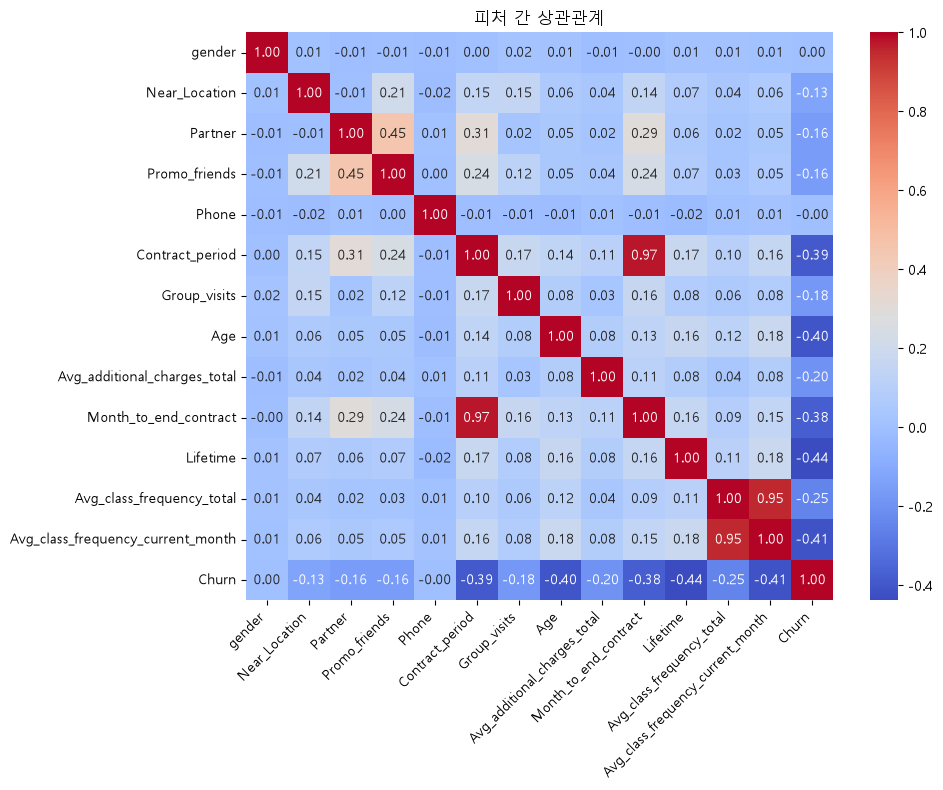

In [13]:
# 피처 간 상관관계
plot_correlation_heatmap(df)
plt.show()

- 분석
    - Churn과 상관계수 절댓값 상위: `Lifetime`(-0.44), `Avg_class_frequency_current_month`(-0.41), `Age`(-0.40), `Contract_period`(-0.39), `Month_to_end_contract`(-0.38)
    - **다중공선성**: `Contract_period` ↔ `Month_to_end_contract` 상관계수 0.97, `Avg_class_frequency_total` ↔ `Avg_class_frequency_current_month` 상관계수 0.95로 매우 높음
    - 두 쌍 모두 강한 다중공선성이 확인되나, 트리 기반 모델(결정트리/랜덤포레스트)은 다중공선성에 상대적으로 강건하여 별도 피처 제거는 진행하지 않음

## 3. 데이터 정제 및 분리

`src/analysis2/train.py`의 `prepare_data`: 전체 컬럼이 이미 숫자형이라 별도 인코딩 없이 X, y만 분리.

In [14]:
from src.analysis2.train import prepare_data

X_train, X_test, y_train, y_test = prepare_data(df)

print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(3200, 13) (800, 13) (3200,) (800,)


## 4. 모델 학습 (고도화 전)

`train_test()`(`src/analysis2/train.py`의 `test4`)를 실행하면 결정트리 / 랜덤포레스트 기본(튜닝 전) 모델을 학습해서
`models/analysis2/*_base.pkl`, `test_data.pkl`로 저장한다.

In [15]:
# 이 셀을 실행하면 models/analysis2/ 에 기본 모델 + 테스트셋이 저장됨
base_score = train_test()
base_score

{'decision_tree': 0.9062, 'random_forest': 0.9275}

## 5. 평가 (고도화 전)

In [16]:
evaluate_test(stage="base")

,Accuracy,Precision,Recall,F1,ROC-AUC
decision_tree,0.9062,0.8341,0.8066,0.8201,0.8744
random_forest,0.9275,0.8850,0.8349,0.8592,0.9676


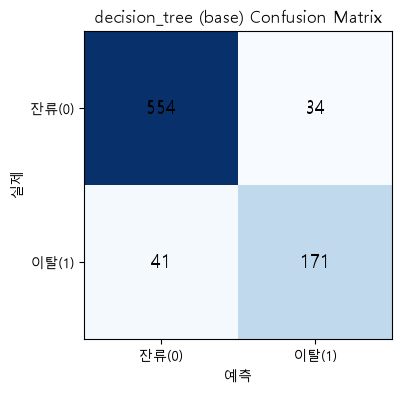

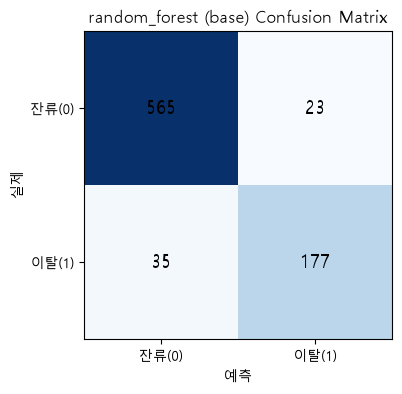

In [17]:
fig1 = plot_confusion_matrix("decision_tree", stage="base")
plt.show()

fig2 = plot_confusion_matrix("random_forest", stage="base")
plt.show()

- 분석
    - Decision Tree: 실제 이탈자 212명 중 41명을 잔류로 잘못 예측 (FN 비율 약 19.3%)
    - Random Forest: 실제 이탈자 212명 중 35명을 잔류로 잘못 예측 (FN 비율 약 16.5%)
    - 두 모델 다 FN 비율이 FP 비율보다 낮아 이탈 감지 성능 자체는 양호한 편. 랜덤포레스트가 FN이 더 적어 이탈자를 놓치지 않는 측면에서 우세

## 6. 모델 고도화 (GridSearchCV)

`scoring="recall"` 기준으로 튜닝 — 이탈자를 놓치지 않는 것이 비즈니스적으로 더 중요하다고 판단.
- 결정트리: `max_depth`, `min_samples_leaf` 탐색
- 랜덤포레스트: `n_estimators`, `max_depth`, `max_features` 탐색

In [18]:
# 이 셀을 실행하면 models/analysis2/*_advanced.pkl 로 튜닝된 모델이 저장됨
best_params = advanced_test()
best_params

{'decision_tree_best_params': {'max_depth': 5, 'min_samples_leaf': 1},
 'random_forest_best_params': {'max_depth': 10,
  'max_features': 'sqrt',
  'n_estimators': 300}}

- 최적 하이퍼파라미터
    - Decision Tree: `max_depth=5, min_samples_leaf=1`
    - Random Forest: `max_depth=10, max_features='sqrt', n_estimators=300`

## 7. 평가 (고도화 후) 및 비교

In [19]:
base_metrics = evaluate_test(stage="base")
adv_metrics = evaluate_test(stage="advanced")

print("고도화 전")
display(base_metrics)
print("고도화 후")
display(adv_metrics)

고도화 전


,Accuracy,Precision,Recall,F1,ROC-AUC
decision_tree,0.9062,0.8341,0.8066,0.8201,0.8744
random_forest,0.9275,0.8850,0.8349,0.8592,0.9676


고도화 후


,Accuracy,Precision,Recall,F1,ROC-AUC
decision_tree,0.9112,0.8439,0.8160,0.8297,0.9381
random_forest,0.9250,0.8878,0.8208,0.8529,0.9694


- 분석
    - 결정트리는 튜닝 후 5개 지표 모두 개선 (특히 ROC-AUC가 0.8744 → 0.9381로 크게 상승)
    - 랜덤포레스트는 튜닝 후 ROC-AUC·Precision은 소폭 상승했지만 Accuracy·Recall·F1은 근소하게 하락 — 기본 모델이 이미 충분히 좋은 성능을 내고 있었음을 시사

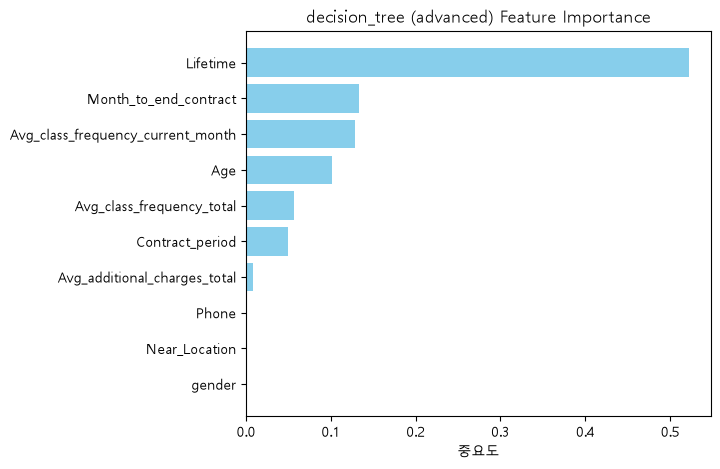

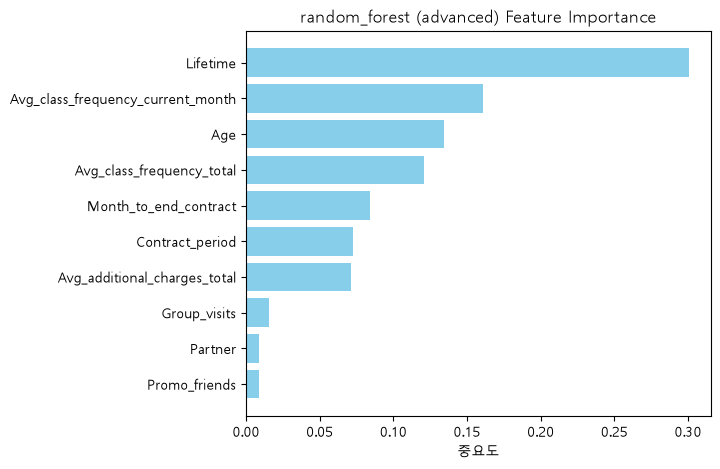

In [20]:
for name in MODEL_NAMES:
    plot_feature_importance(name, stage="advanced")
    plt.show()

- 분석
    - 두 모델 모두 `Lifetime`(가입기간)이 압도적 1위 중요도
    - 다음으로 `Avg_class_frequency_current_month`(최근 수업참여빈도), `Age`(연령) 순
    - `gender`, `Near_Location`, `Phone` 등 인구통계·접근성 피처는 중요도가 낮게 나타나, 이탈 예측에는 인구통계보다 **실제 이용 행동 패턴**이 훨씬 중요하다는 인사이트

## 8. 최종 결과 및 결론

- **최종 채택 모델: Random Forest (advanced)**
- 선정 근거: Accuracy·Recall·F1·ROC-AUC 전 지표에서 결정트리보다 일관되게 우수. 특히 Recall이 높아 이탈 위험 회원을 놓치지 않는 비즈니스 목적에 더 부합
- 비즈니스 인사이트: 가입기간(Lifetime)이 짧고 최근 수업 참여빈도가 낮은 회원일수록 이탈 위험이 높음
  → 가입 초반 회원 대상 온보딩 강화, 수업 참여 빈도 급감 회원 대상 알림·할인 쿠폰 발송 등의 리텐션 전략 제안 가능
- 한계: 전체 데이터가 4,000건으로 규모가 크지 않고 이탈률(26.5%)이 다소 불균형 → 향후 SMOTE 등 오버샘플링 검토, XGBoost·딥러닝 MLP와의 비교 필요